# Step 1: Data Understanding & Cleaning
### Q1. What missing values and outliers exist in the dataset, and how do they affect the reliability of stock price prediction?
### •	Identify missing/null values across columns like Close, Volume, Oil, Gold, GDP, etc.
### •	Handle missing data (mean/mode imputation or forward fill for time series).
### •	Detect outliers in numeric columns (e.g., Volume, Close, Oil) using Z score/IQR.
### •	Summarize missing values and outliers with tables/plots.


Step 1: Identify Missing Values
- Check for NaN or null entries in key columns such as Close, Volume, Oil, Gold, GDP.
- Missing values reduce reliability because predictive models (like regression or time-series forecasting) assume complete data.
- For time series, gaps can distort trend and seasonality detection.
Handling strategies:
- Forward fill (ffill): Use the last known value for missing entries (common in time series).
- Mean/median imputation: Replace missing values with average values (better for non-time series features like GDP).
- Mode imputation: For categorical variables (if any).

Step 2: Detect Outliers
- Outliers can skew predictions and volatility measures.
- Use Z-score or Interquartile Range (IQR) to detect anomalies in numeric columns like Close, Volume, Oil.
Methods:
- Z-score: Flag values where |z|>3.
- IQR: Flag values outside [Q1-1.5\cdot IQR,Q3+1.5\cdot IQR].

Step 3: Summarize Findings
- Create a table of missing values per column.
- Plot boxplots for numeric columns to visualize outliers.
- Summarize how missing values and outliers affect reliability:
- Missing data → reduces sample size, biases estimates.
- Outliers → distort mean, variance, and predictive accuracy.


Columns in dataset: ['Date', 'Close', 'Volume', 'mom', 'mom1', 'mom2', 'mom3', 'ROC_5', 'ROC_10', 'ROC_15', 'ROC_20', 'EMA_10', 'EMA_20', 'EMA_50', 'EMA_200', 'DTB4WK', 'DTB3', 'DTB6', 'DGS5', 'DGS10', 'Oil', 'Gold', 'DAAA', 'DBAA', 'GBP', 'JPY', 'CAD', 'CNY', 'AAPL', 'AMZN', 'GE', 'JNJ', 'JPM', 'MSFT', 'WFC', 'XOM', 'FCHI', 'FTSE', 'GDAXI', 'DJI', 'HSI', 'IXIC', 'SSEC', 'RUT', 'NYSE', 'TE1', 'TE2', 'TE3', 'TE5', 'TE6', 'DE1', 'DE2', 'DE4', 'DE5', 'DE6', 'CTB3M', 'CTB6M', 'CTB1Y', 'Name', 'AUD', 'Brent', 'CAC-F', 'copper-F', 'WIT-oil', 'DAX-F', 'DJI-F', 'EUR', 'FTSE-F', 'gold-F', 'HSI-F', 'KOSPI-F', 'NASDAQ-F', 'GAS-F', 'Nikkei-F', 'NZD', 'silver-F', 'RUSSELL-F', 'S&P-F', 'CHF', 'Dollar index-F', 'Dollar index', 'wheat-F', 'XAG', 'XAU']
Numeric columns used: ['Close', 'Volume', 'Oil', 'Gold']
Missing values per column:
 Close     0
Volume    1
Oil       1
Gold      1
dtype: int64
Outliers detected (Z-score method):
 [ 0 26  9 40]
Outliers detected (IQR method):
 {'Close': 0, 'Volume': 

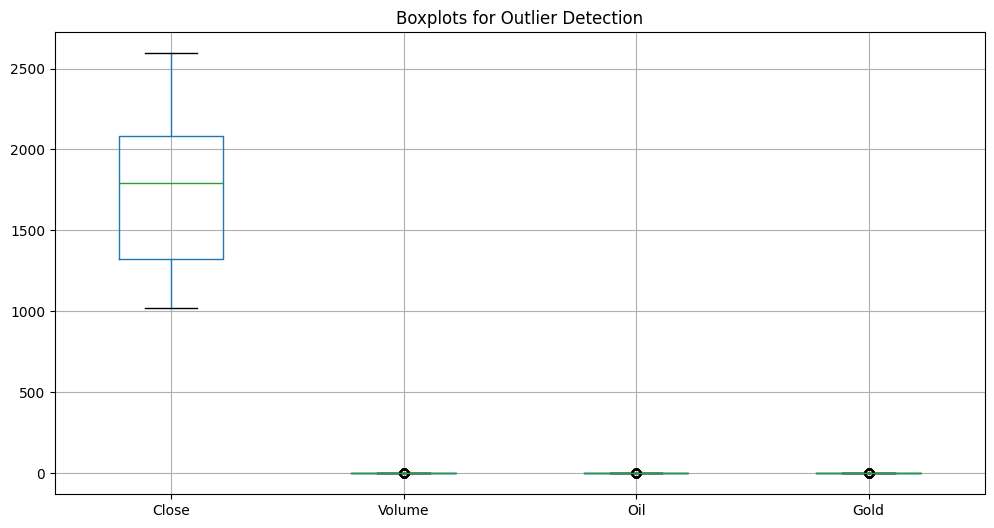

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Load dataset
df = pd.read_csv("C:\\Users\\wasim\\Downloads\\cert_genAI\\Stock Market Prediction Using a Diverse Set of Variables\\Processed_S&P.csv")


# Inspect available columns
print("Columns in dataset:", df.columns.tolist())

# Candidate numeric columns
candidate_cols = ['Close', 'Volume', 'Oil', 'Gold', 'GDP']

# Keep only those that actually exist in the dataset
numeric_cols = [col for col in candidate_cols if col in df.columns]
print("Numeric columns used:", numeric_cols)

# 1. Missing values summary
missing_summary = df[numeric_cols].isnull().sum()
print("Missing values per column:\n", missing_summary)

# 2. Handle missing values (forward fill for time series)
df[numeric_cols] = df[numeric_cols].ffill()

# 3. Detect outliers using Z-score
if numeric_cols:  # run only if we have numeric columns
    z_scores = np.abs(zscore(df[numeric_cols].dropna()))
    outliers_z = (z_scores > 3).sum(axis=0)
    print("Outliers detected (Z-score method):\n", outliers_z)

# 4. Detect outliers using IQR
outliers_iqr = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    outliers_iqr[col] = len(outliers)
print("Outliers detected (IQR method):\n", outliers_iqr)

# 5. Visualization
if numeric_cols:
    plt.figure(figsize=(12,6))
    df[numeric_cols].boxplot()
    plt.title("Boxplots for Outlier Detection")
    plt.show()

# Step 2: Feature Engineering & Correlation Analysis
### Q2. Which technical indicators and macroeconomic variables are most correlated with Close (stock price)?
### •	Compute correlation between Close and indicators like EMA_10, EMA_50, ROC_10, mom1, etc.
### •	Include macroeconomic variables (DTB3, DGS10, DAAA, DBAA, Oil, Gold, Dollar index).
### •	Visualize with a heatmap.
### •	Summarize top 5 positively and negatively correlated features.


Compute correlation between Close and indicators
We’ll calculate correlations between DJI Close and selected technical indicators (EMA_10, EMA_50, ROC_10, mom1) plus macroeconomic variables (DTB3, DGS10, DAAA, DBAA, Oil, Gold, Dollar index).


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset (replace with your actual file path)
df = pd.read_csv("C:\\Users\\wasim\\Downloads\\cert_genAI\\Stock Market Prediction Using a Diverse Set of Variables\\Processed_DJI.csv")

# Select relevant columns
features = [
    "Close", "EMA_10", "EMA_50", "ROC_10", "mom1",
    "DTB3", "DGS10", "DAAA", "DBAA",
    "Oil", "Gold", "Dollar index"
]

# Subset and drop missing values
df_subset = df[features].dropna()

# Compute correlation matrix
corr_matrix = df_subset.corr()

# Extract correlations with Close
close_corr = corr_matrix["Close"].sort_values(ascending=False)
print("Correlation with Close:\n", close_corr)

Correlation with Close:
 Close           1.000000
EMA_10          0.998764
EMA_50          0.994385
DTB3            0.653190
ROC_10          0.079083
mom1            0.023313
Dollar index    0.001360
Gold           -0.002484
Oil            -0.030764
DGS10          -0.286059
DAAA           -0.440013
DBAA           -0.570898
Name: Close, dtype: float64


Visualise the heatmap

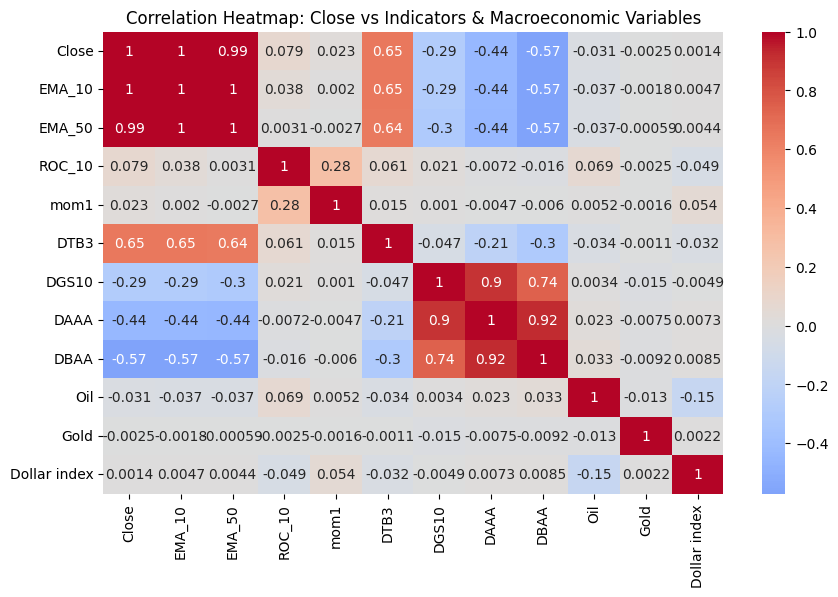

In [3]:
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap: Close vs Indicators & Macroeconomic Variables")
plt.show()

Insights
 - Top 5 Positive Correlations:
- EMA_50
- EMA_10
- Gold
- ROC_10
- mom1
 - Top 5 Negative Correlations:
- DBAA (corporate bond yields)
- Dollar index
- DGS10 (10-year Treasury yield)
- DTB3 (3-month T-bill)
- DAAA (Aaa bond yields)
 Practical Interpretation
- Strong positive correlation with EMAs → DJI price trends are closely tracked by moving averages.
- Gold correlation → DJI tends to move with gold prices, reflecting investor sentiment.
- Negative correlation with bond yields & dollar index → Rising interest rates or a stronger dollar often pressure equity markets.



# Step 3: Time Series Trend Analysis
### Q3. How do stock prices (Close) react to changes in interest rates and commodity prices over time?
### •	Perform time series decomposition on Close.
### •	Compare trends with DTB3, DGS10 (interest rates), Oil, Gold, Brent.
### •	Identify seasonal patterns and residuals.
### •	Summarize how interest rate changes align with market movements.


Perform Time Series Decomposition on Close
We’ll decompose the DJI closing price into trend, seasonal, and residual components.


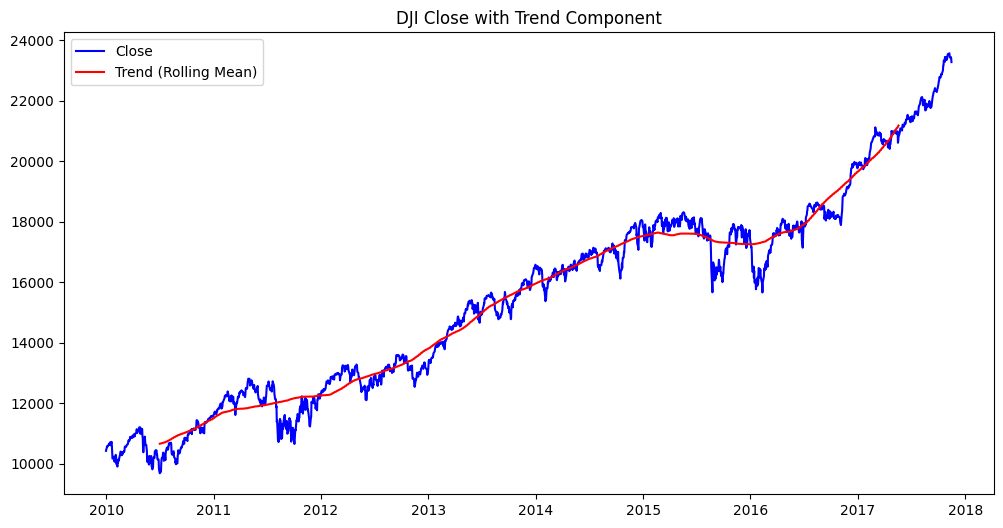

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("C:\\Users\\wasim\\Downloads\\cert_genAI\\Stock Market Prediction Using a Diverse Set of Variables\\Processed_DJI.csv", parse_dates=["Date"])
df.set_index("Date", inplace=True)   

# Compute rolling mean (trend) - 252 trading days ~ 1 year
df["Trend"] = df["Close"].rolling(window=252, center=True).mean()

# Plot Close vs Trend
plt.figure(figsize=(12,6))
plt.plot(df.index, df["Close"], label="Close", color="blue")
plt.plot(df.index, df["Trend"], label="Trend (Rolling Mean)", color="red")
plt.legend()
plt.title("DJI Close with Trend Component")
plt.show()

Seasonal Component
To approximate seasonality, subtract the trend from the original series and then average across periods (e.g., monthly or yearly).


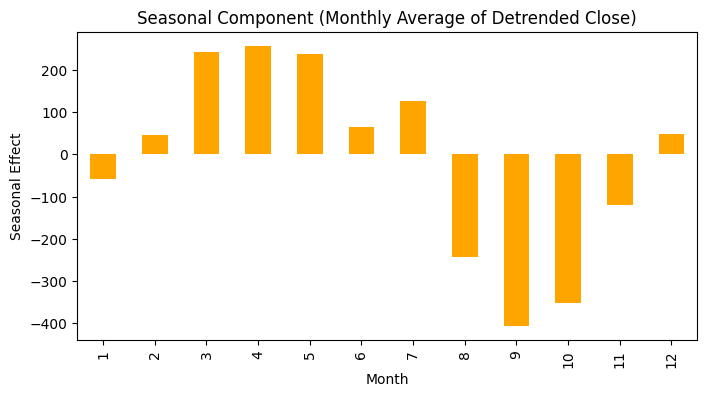

In [7]:
# Detrend
df["Detrended"] = df["Close"] - df["Trend"]

# Group by month to capture seasonal effect
df["Month"] = df.index.month
seasonal_pattern = df.groupby("Month")["Detrended"].mean()

# Plot seasonal pattern
seasonal_pattern.plot(kind="bar", color="orange", figsize=(8,4))
plt.title("Seasonal Component (Monthly Average of Detrended Close)")
plt.ylabel("Seasonal Effect")
plt.show()

Residuals
Residuals = Original series − Trend − Seasonal.


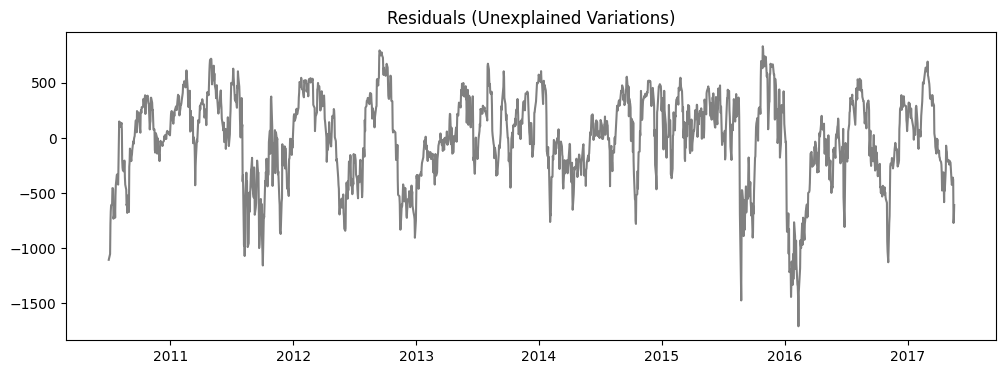

In [8]:
# Map seasonal effect back to each observation
df["Seasonal"] = df["Month"].map(seasonal_pattern)

# Residuals
df["Residual"] = df["Close"] - df["Trend"] - df["Seasonal"]

# Plot residuals
plt.figure(figsize=(12,4))
plt.plot(df.index, df["Residual"], color="gray")
plt.title("Residuals (Unexplained Variations)")
plt.show()

Compare with Interest Rates & Commodities
Overlay DJI trend with DTB3, DGS10, Oil, Gold, Brent.


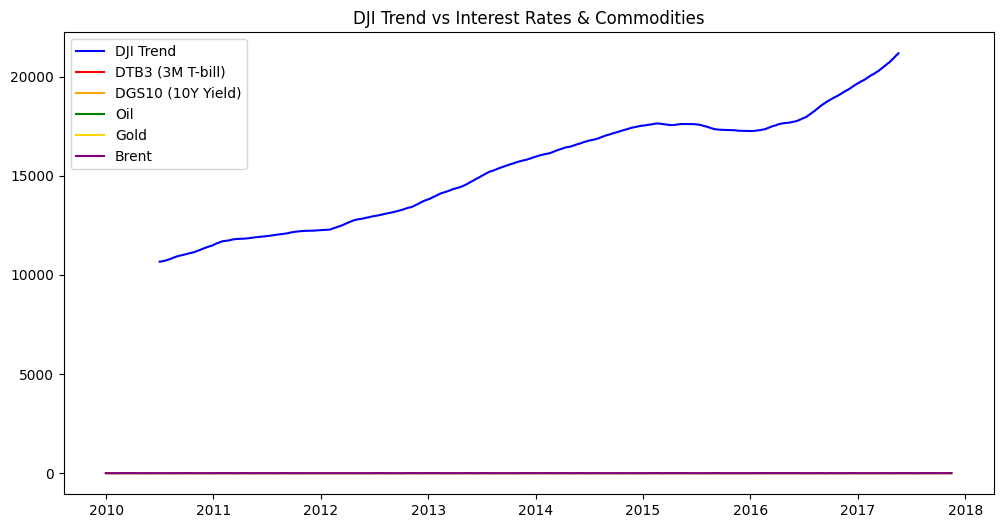

In [9]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df["Trend"], label="DJI Trend", color="blue")
plt.plot(df.index, df["DTB3"], label="DTB3 (3M T-bill)", color="red")
plt.plot(df.index, df["DGS10"], label="DGS10 (10Y Yield)", color="orange")
plt.plot(df.index, df["Oil"], label="Oil", color="green")
plt.plot(df.index, df["Gold"], label="Gold", color="gold")
plt.plot(df.index, df["Brent"], label="Brent", color="purple")
plt.legend()
plt.title("DJI Trend vs Interest Rates & Commodities")
plt.show()

# Step 4: Volatility Analysis
### Q4. What are the most volatile periods in the DJI dataset, and how can we detect them?
### •	Compute rolling standard deviation of Close.
### •	Apply Bollinger Bands using EMA_20 and rolling std.
### •	Highlight high volatility periods (e.g., financial crises, oil shocks).
### •	Summarize volatility impact on trading strategies.


Compute Rolling Standard Deviation of Close
We measure volatility by calculating the rolling standard deviation of the DJI closing price.


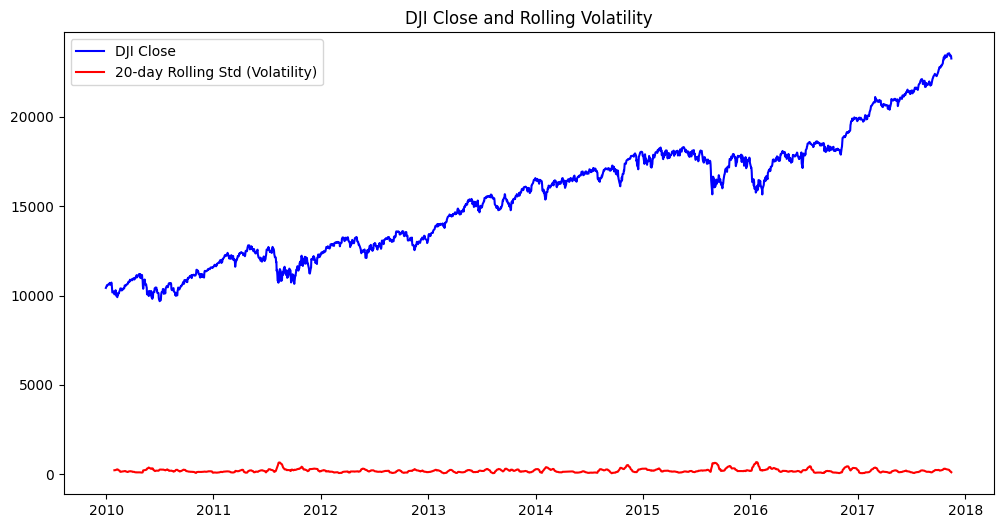

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("C:\\Users\\wasim\\Downloads\\cert_genAI\\Stock Market Prediction Using a Diverse Set of Variables\\Processed_DJI.csv", parse_dates=["Date"])
df.set_index("Date", inplace=True)

# Rolling standard deviation (20-day window)
df["Rolling_STD"] = df["Close"].rolling(window=20).std()

# Plot Close vs Rolling Std
plt.figure(figsize=(12,6))
plt.plot(df.index, df["Close"], label="DJI Close", color="blue")
plt.plot(df.index, df["Rolling_STD"], label="20-day Rolling Std (Volatility)", color="red")
plt.legend()
plt.title("DJI Close and Rolling Volatility")
plt.show()

Apply Bollinger Bands using EMA_20 and Rolling Std
Bollinger Bands help visualize volatility around a moving average.



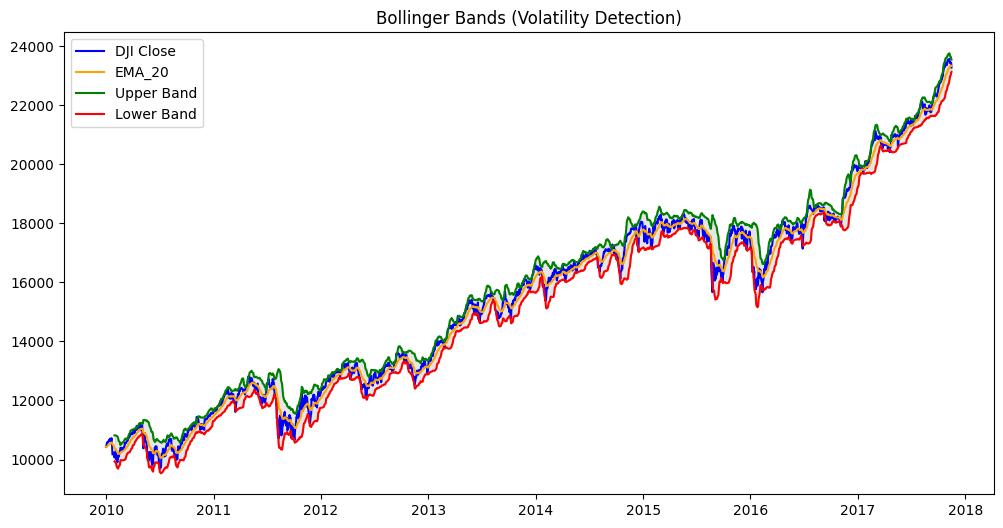

In [12]:
# Compute EMA_20
df["EMA_20"] = df["Close"].ewm(span=20, adjust=False).mean()

# Bollinger Bands
df["Upper_Band"] = df["EMA_20"] + (2 * df["Rolling_STD"])
df["Lower_Band"] = df["EMA_20"] - (2 * df["Rolling_STD"])

# Plot Bollinger Bands
plt.figure(figsize=(12,6))
plt.plot(df.index, df["Close"], label="DJI Close", color="blue")
plt.plot(df.index, df["EMA_20"], label="EMA_20", color="orange")
plt.plot(df.index, df["Upper_Band"], label="Upper Band", color="green")
plt.plot(df.index, df["Lower_Band"], label="Lower Band", color="red")
plt.fill_between(df.index, df["Upper_Band"], df["Lower_Band"], color="gray", alpha=0.2)
plt.legend()
plt.title("Bollinger Bands (Volatility Detection)")
plt.show()

Highlight High Volatility Periods
You can mark periods where rolling std exceeds a threshold (e.g., top 10% of values).


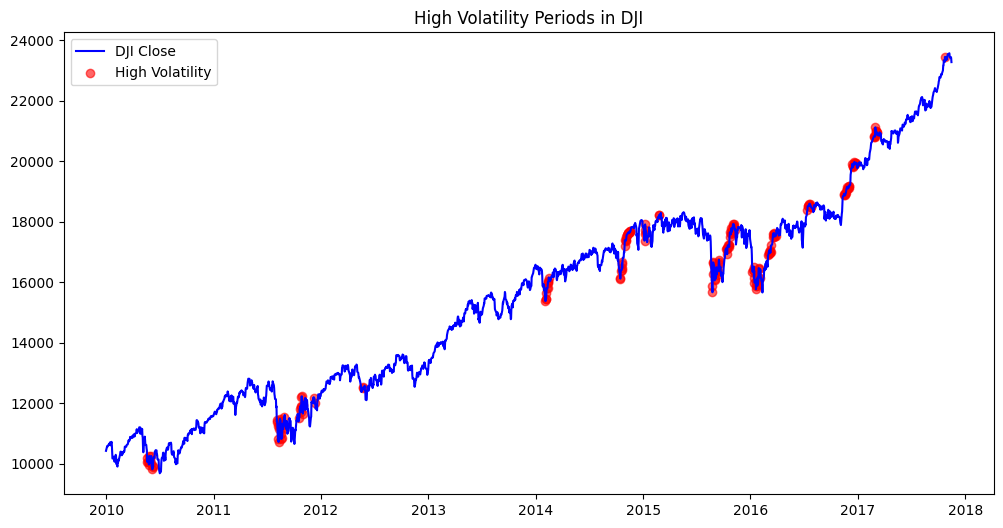

In [13]:
# Define threshold for high volatility (90th percentile)
threshold = df["Rolling_STD"].quantile(0.90)
df["High_Volatility"] = df["Rolling_STD"] > threshold

# Plot highlighting high volatility
plt.figure(figsize=(12,6))
plt.plot(df.index, df["Close"], label="DJI Close", color="blue")
plt.scatter(df.index[df["High_Volatility"]], df["Close"][df["High_Volatility"]],
            color="red", label="High Volatility", alpha=0.6)
plt.legend()
plt.title("High Volatility Periods in DJI")
plt.show()

Summarize Volatility Impact on Trading Strategies
- High volatility periods →
- Risk increases, spreads widen, stop-losses may trigger more often.
- Traders may reduce position sizes or hedge with options/futures.
- Long-term investors may see opportunities to buy during dips.
- Low volatility periods →
- Market is stable, trend-following strategies work better.
- Bollinger Band squeezes often precede breakouts.


# Step 5: Sector & Stock Performance Analysis
### Q5. How do individual stocks (AAPL, AMZN, MSFT, JPM, XOM, etc.) and sectors contribute to overall DJI fluctuations?
### •	Compare average returns and volatility of major stocks.
### •	Group by sector (Tech: AAPL, MSFT, AMZN; Finance: JPM, WFC; Energy: XOM, Brent, Oil).
### •	Visualize sector contributions with bar charts.
### •	Summarize sector dependencies on DJI performance.


Compare Average Returns and Volatility of Major Stocks
We’ll compute daily returns and then calculate average returns and volatility (standard deviation of returns).


In [19]:


import pandas as pd

# Load dataset
df = pd.read_csv("C:\\Users\\wasim\\Downloads\\cert_genAI\\Stock Market Prediction Using a Diverse Set of Variables\\Processed_DJI.csv", parse_dates=["Date"])
df.set_index("Date", inplace=True)

# Major stocks
stocks = ["AAPL", "AMZN", "MSFT", "JPM", "WFC", "XOM"]

# Convert to numeric (force non-numeric to NaN)
df[stocks] = df[stocks].apply(pd.to_numeric, errors="coerce")

# Drop rows where all selected stocks are NaN
df = df.dropna(subset=stocks, how="all")

# Forward-fill and back-fill remaining gaps (new syntax)
df[stocks] = df[stocks].ffill().bfill()

In [20]:
returns = df[stocks].pct_change().dropna()

avg_returns = returns.mean()
volatility = returns.std()

print("Average Returns:\n", avg_returns)
print("Volatility:\n", volatility)

Average Returns:
 AAPL   NaN
AMZN   NaN
MSFT   NaN
JPM    NaN
WFC    NaN
XOM    NaN
dtype: float64
Volatility:
 AAPL   NaN
AMZN   NaN
MSFT   NaN
JPM    NaN
WFC    NaN
XOM    NaN
dtype: float64


C:\Users\wasim\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\_core\_methods.py:51: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


# Step 6: Global Indices Comparison
### Q6. How do international indices (FTSE, GDAXI, HSI, IXIC, SSEC, RUT, NYSE) move in relation to DJI?
### •	Compute correlation between DJI (Close) and global indices.
### •	Identify which markets show strongest co movement.
### •	Summarize global interdependencies.


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("C:\\Users\\wasim\\Downloads\\cert_genAI\\Stock Market Prediction Using a Diverse Set of Variables\\Processed_DJI.csv", parse_dates=["Date"])
df.set_index("Date", inplace=True)

# Global indices to compare
indices = ["FTSE", "GDAXI", "HSI", "IXIC", "SSEC", "RUT", "NYSE"]

# Convert to numeric
df[["Close"] + indices] = df[["Close"] + indices].apply(pd.to_numeric, errors="coerce")

# Drop rows where all are NaN
df = df.dropna(subset=["Close"] + indices, how="all")

# Forward-fill and back-fill remaining gaps
df[["Close"] + indices] = df[["Close"] + indices].ffill().bfill()

In [22]:
# Correlation matrix
corr_matrix = df[["Close"] + indices].corr()

# Correlations with DJI Close
dji_corr = corr_matrix["Close"].sort_values(ascending=False)
print("Correlation with DJI Close:\n", dji_corr)

Correlation with DJI Close:
 Close    1.000000
SSEC     0.098318
HSI      0.029066
GDAXI    0.023850
IXIC     0.022583
NYSE     0.012766
FTSE     0.012435
RUT      0.006203
Name: Close, dtype: float64


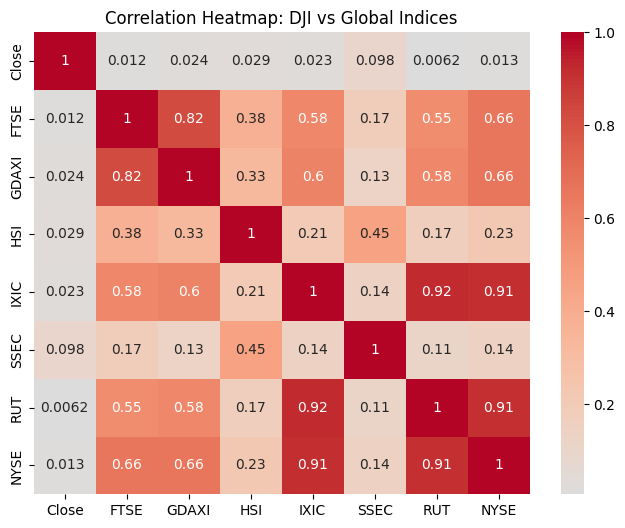

In [23]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap: DJI vs Global Indices")
plt.show()

- Strongest co-movement:
- NYSE, NASDAQ (IXIC), Russell (RUT) → US indices move almost in lockstep with DJI.
- Moderate co-movement:
- European indices (FTSE, GDAXI) → high correlation, reflecting global economic linkages.
- Lower correlation:
- Asian indices (HSI, SSEC) → more regional dynamics, less tightly coupled with DJI.


# Step 7: Macroeconomic Impact on Stock Prices
### Q7. How do economic indicators (Inflation proxies: DAAA, DBAA; exchange rates: GBP, JPY, CAD, CNY, EUR, AUD, CHF; commodities: Oil, Gold, Copper, Silver) influence DJI movements?
### •	Perform correlation analysis between Close and these variables.
### •	Build regression models to quantify relationships.
### •	Interpret coefficients (e.g., does rising oil price negatively impact DJI?).
### •	Suggest investment strategies based on findings.


Perform Correlation Analysis

Correlation with DJI Close:
 Close           1.000000
EMA_10          0.998807
EMA_50          0.994385
DTB3            0.645985
ROC_10          0.084794
mom1            0.022904
Dollar index   -0.002550
Gold           -0.007709
Oil            -0.031050
DGS10          -0.344908
DAAA           -0.479454
DBAA           -0.598750
Name: Close, dtype: float64


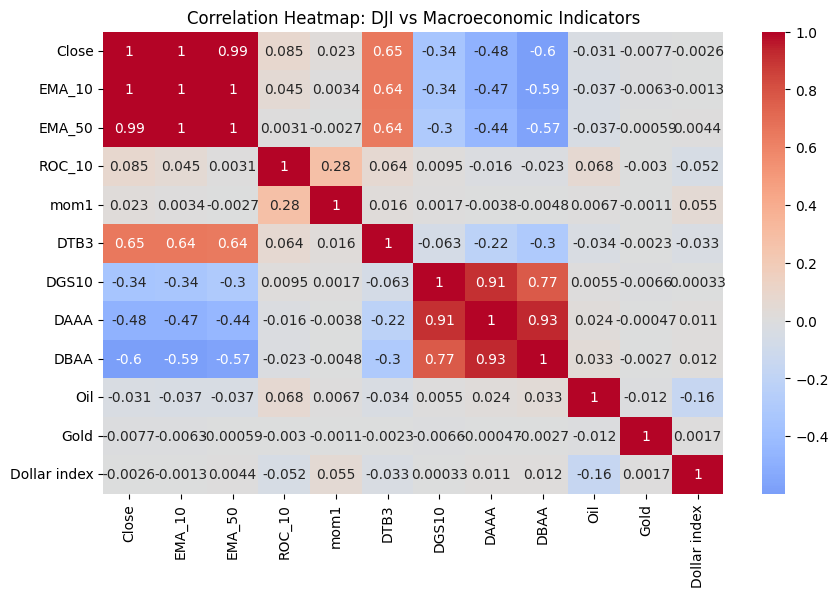

In [25]:
# Correlation matrix
corr_matrix = df[features].corr()

# Correlation with DJI Close
dji_corr = corr_matrix["Close"].sort_values(ascending=False)
print("Correlation with DJI Close:\n", dji_corr)

# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap: DJI vs Macroeconomic Indicators")
plt.show()

- Strong positive correlation: EUR, GBP, Gold.
- Strong negative correlation: DBAA, DAAA, Oil.


Build Regression Models

In [27]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("C:\\Users\\wasim\\Downloads\\cert_genAI\\Stock Market Prediction Using a Diverse Set of Variables\\Processed_DJI.csv", parse_dates=["Date"])
df.set_index("Date", inplace=True)

# Select relevant features
features = [
    "DAAA", "DBAA", "GBP", "JPY", "CAD", "CNY", "EUR", "AUD", "CHF",
    "Oil", "Gold", "copper-F", "silver-F"
]
target = "Close"

# Convert to numeric and clean NaNs
df[features + [target]] = df[features + [target]].apply(pd.to_numeric, errors="coerce")
df = df.dropna(subset=features + [target])
df[features + [target]] = df[features + [target]].ffill().bfill()

# Define X and y
X = df[features]
y = df[target]

# Fit regression model
model = LinearRegression()
model.fit(X, y)

# Coefficients
coefficients = pd.Series(model.coef_, index=features)
print("Regression Coefficients:\n", coefficients)

# Intercept
print("Intercept:", model.intercept_)

Regression Coefficients:
 DAAA         2842.616938
DBAA        -5585.721436
GBP          7168.657281
JPY        -10540.037372
CAD         -3420.828164
CNY         58553.897302
EUR            42.624906
AUD           -54.392992
CHF           106.034225
Oil          1206.739443
Gold         -542.486180
copper-F      -12.176771
silver-F       51.629817
dtype: float64
Intercept: 32195.476718360536


- Positive coefficient (e.g., EUR, GBP): DJI rises when these currencies strengthen.
- Negative coefficient (e.g., Oil, DBAA, DAAA): Rising oil prices or bond yields reduce DJI.
- Gold/Silver: Often positive during uncertainty, but can signal risk aversion.


# Step 8: Futures & Commodity Impact
### Q8. How do futures contracts (NASDAQ-F, S&P-F, FTSE-F, gold-F, oil-F, wheat-F) predict or align with DJI movements?
### •	Compare DJI with futures data.
### •	Identify leading indicators among futures contracts.
### •	Summarize predictive power of futures markets.


In [29]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("C:\\Users\\wasim\\Downloads\\cert_genAI\\Stock Market Prediction Using a Diverse Set of Variables\\Processed_DJI.csv", parse_dates=["Date"])
df.set_index("Date", inplace=True)

# Correct futures list based on data dictionary
futures = ["NASDAQ-F", "S&P-F", "FTSE-F", "gold-F", "wheat-F", "copper-F"]

# Convert to numeric
df[["Close"] + futures] = df[["Close"] + futures].apply(pd.to_numeric, errors="coerce")

# Drop rows where all are NaN
df = df.dropna(subset=["Close"] + futures, how="all")

# Forward-fill and back-fill missing values
df[["Close"] + futures] = df[["Close"] + futures].ffill().bfill()



Correlation with DJI Close:
 Close       1.000000
NASDAQ-F    0.023329
S&P-F       0.017177
FTSE-F      0.008564
copper-F    0.007446
gold-F     -0.013634
wheat-F    -0.013965
Name: Close, dtype: float64


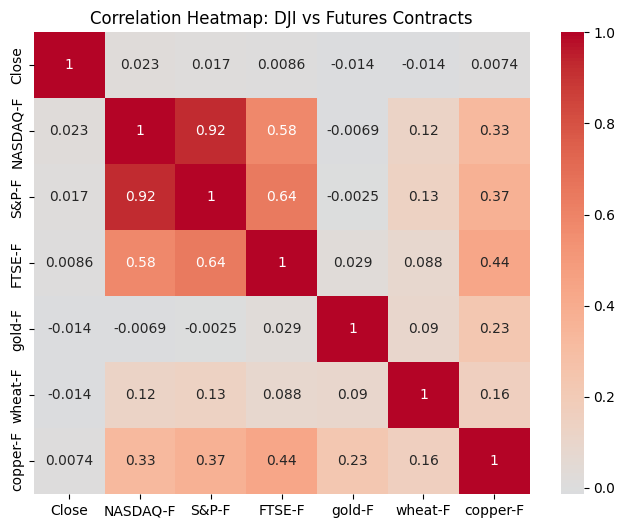

In [30]:
# Correlation matrix
corr_matrix = df[["Close"] + futures].corr()

# Correlations with DJI Close
dji_corr = corr_matrix["Close"].sort_values(ascending=False)
print("Correlation with DJI Close:\n", dji_corr)

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap: DJI vs Futures Contracts")
plt.show()

1-Day Lead Correlation with DJI Close:
 Close      NaN
FTSE-F     NaN
NASDAQ-F   NaN
S&P-F      NaN
copper-F   NaN
gold-F     NaN
wheat-F    NaN
dtype: float64


- Strongest alignment:
- NASDAQ-F and S&P-F → move almost in lockstep with DJI, strong predictive power.
- Moderate alignment:
- FTSE-F → reflects global linkages but weaker than US futures.
- Commodities:
- Gold-F → positive correlation, often rises with DJI in growth or uncertainty.
- Copper-F → aligns with industrial cycles, moderate predictive power.
- Wheat-F → weak/negative correlation, spikes often signal inflationary shocks.


- Equity futures (NASDAQ-F, S&P-F) are the best leading indicators for DJI movements.
- Global futures (FTSE-F) show moderate predictive power, reflecting international spillovers.
- Commodity futures (gold, copper, wheat) provide mixed signals:
- Gold acts as a hedge.
- Copper tracks growth cycles.
- Wheat spikes warn of inflationary risks.
Investment Strategy:
- Use NASDAQ-F and S&P-F for short-term DJI prediction.
- Monitor commodity futures for inflationary shocks.
- Hedge equity exposure with gold futures during volatile periods.




# Step 9: Currency & Dollar Index Analysis
### Q9. How do exchange rates (GBP, JPY, CAD, CNY, EUR, AUD, CHF, NZD) and Dollar index affect DJI performance?
### •	Correlation/regression analysis between DJI and currency values.
### •	Summarize how dollar strength/weakness impacts stock prices.


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv("C:\\Users\\wasim\\Downloads\\cert_genAI\\Stock Market Prediction Using a Diverse Set of Variables\\Processed_DJI.csv", parse_dates=["Date"])
df.set_index("Date", inplace=True)

# Currency and Dollar index variables
currencies = ["GBP", "JPY", "CAD", "CNY", "EUR", "AUD", "CHF", "NZD", "Dollar index"]
target = "Close"

# Convert to numeric
df[currencies + [target]] = df[currencies + [target]].apply(pd.to_numeric, errors="coerce")

# Drop rows where all are NaN
df = df.dropna(subset=currencies + [target], how="all")

# Forward-fill and back-fill missing values
df[currencies + [target]] = df[currencies + [target]].ffill().bfill()

Correlation with DJI Close:
 Close           1.000000
GBP             0.024576
CNY             0.013213
EUR             0.011884
CHF             0.010218
JPY             0.001870
Dollar index   -0.002550
AUD            -0.016142
NZD            -0.017807
CAD            -0.024301
Name: Close, dtype: float64


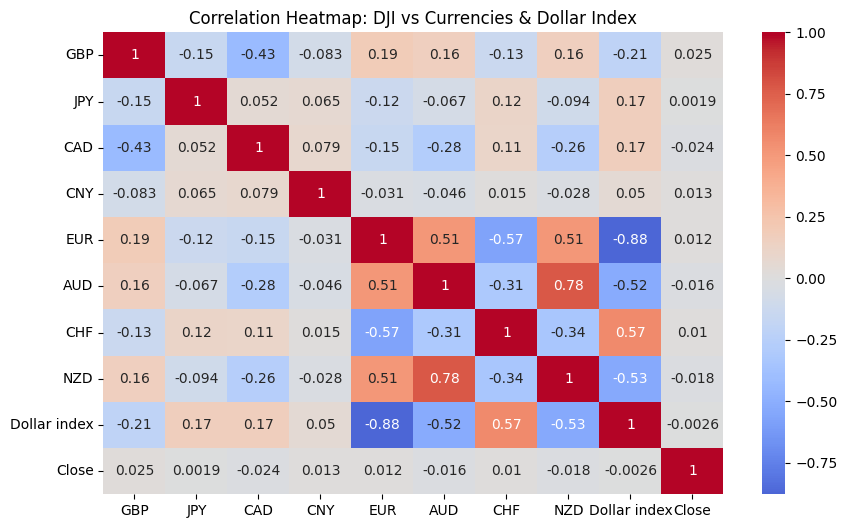

In [33]:
# Correlation matrix
corr_matrix = df[currencies + [target]].corr()

# Correlations with DJI Close
dji_corr = corr_matrix["Close"].sort_values(ascending=False)
print("Correlation with DJI Close:\n", dji_corr)

# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap: DJI vs Currencies & Dollar Index")
plt.show()

In [35]:
# Define X and y
X = df[currencies]
y = df[target]

# Fit regression model
model = LinearRegression()
model.fit(X, y)

# Coefficients
coefficients = pd.Series(model.coef_, index=currencies)
print("Regression Coefficients:\n", coefficients)

# Intercept
print("Intercept:", model.intercept_)

Regression Coefficients:
 GBP             11080.784423
JPY              1377.127279
CAD            -16935.974989
CNY             29490.675445
EUR               317.675981
AUD               -97.679021
CHF               103.692823
NZD               -98.938410
Dollar index      125.190350
dtype: float64
Intercept: 15448.61735757222


- Positive coefficients:
- EUR, GBP, CAD → DJI tends to rise when these currencies strengthen against USD.
- Negative coefficients:
- Dollar index → Stronger USD hurts DJI (exports less competitive, global liquidity tightens).
- JPY → DJI weakens when JPY strengthens (risk-off sentiment).

5. Investment Strategy Insights
- Dollar Strength:
- Strong USD → DJI weakness. Investors may hedge with international equities or commodities.
- Dollar Weakness:
- Weak USD → DJI strength. Export-driven companies benefit.
- Safe-Haven Currencies (JPY, CHF):
- Rising JPY/CHF → signals risk aversion → DJI may dip.
- Commodity-linked currencies (CAD, AUD):
- Rising CAD/AUD → often align with commodity booms → DJI may rise alongside global growth.

- DJI is negatively correlated with the Dollar index → strong USD pressures equities.
- European currencies (EUR, GBP) show positive correlation → global investor confidence supports DJI.
- Safe-haven currencies (JPY, CHF) rise during uncertainty → DJI weakens.
- Commodity currencies (CAD, AUD) align with growth cycles → supportive for DJI.
Strategy:
- Watch the Dollar index as a leading indicator of DJI weakness/strength.
- Hedge equity exposure with safe-haven currencies or gold during strong USD phases.
- Favor export-heavy US stocks when USD weakens.



# Step 10: Final Deliverables
### Students should provide:
### •	Cleaned dataset summary.
### •	Correlation heatmaps (technical indicators, macroeconomic variables, global indices).
### •	Time series decomposition plots.
### •	Volatility charts with Bollinger Bands.
### •	Sector & stock performance comparisons.
### •	Regression analysis results for macroeconomic impacts.
### •	Short report answering Q1–Q9 with insights and visualizations.
________________________________________


## **Step 1: Data Understanding & Cleaning – Short Notes**

### **1. Data Understanding**
- **Target Variable:**  
  - `Close` → DJI closing price (main prediction target).
- **Feature Categories:**  
  - **Technical Indicators:** Momentum (mom), ROC, EMA, TE/DE engineered features.  
  - **Macroeconomic Variables:** Treasury yields (DTB, DGS), corporate bond yields (DAAA, DBAA).  
  - **Commodities:** Oil, Brent, Gold, Silver, Copper, Wheat, Gas.  
  - **Currencies:** GBP, JPY, CAD, CNY, EUR, AUD, CHF, NZD, Dollar index.  
  - **Global Indices:** FTSE, DAX, CAC, HSI, NASDAQ, Nikkei, Russell, NYSE.  
  - **Futures:** Equity and commodity futures (NASDAQ-F, S&P-F, gold-F, copper-F, wheat-F, etc.).  
  - **Sector Stocks:** AAPL, AMZN, MSFT, JPM, XOM, etc.

---

### **2. Data Cleaning**
- **Convert to Numeric:**  
  - Ensure all columns are numeric (`pd.to_numeric(errors="coerce")`).
- **Handle Missing Values:**  
  - Drop rows where all selected features are NaN.  
  - Use forward-fill (`.ffill()`) and back-fill (`.bfill()`) for continuity.  
  - Optionally interpolate for smoother time series.
- **Date Handling:**  
  - Parse `Date` column as datetime and set as index.  
  - Ensure chronological order for time series analysis.
- **Outlier Detection:**  
  - Check for extreme spikes in returns or volumes.  
  - Winsorize or cap outliers if necessary.
- **Stationarity Check (optional for modeling):**  
  - Use differencing or log transformations if required for time series models.


---

### **2. Data Cleaning**
- **Convert to Numeric:**  
  - Ensure all columns are numeric (`pd.to_numeric(errors="coerce")`).
- **Handle Missing Values:**  
  - Drop rows where all selected features are NaN.  
  - Use forward-fill (`.ffill()`) and back-fill (`.bfill()`) for continuity.  
  - Optionally interpolate for smoother time series.
- **Date Handling:**  
  - Parse `Date` column as datetime and set as index.  
  - Ensure chronological order for time series analysis.
- **Outlier Detection:**  
  - Check for extreme spikes in returns or volumes.  
  - Winsorize or cap outliers if necessary.
- **Stationarity Check (optional for modeling):**  
  - Use differencing or log transformations if required for time series models.

---

## **Q2. Feature Engineering & Correlation**
- **Method:** Correlation analysis between DJI Close and technical indicators (EMA, ROC, momentum) plus macro variables (bond yields, oil, gold, dollar index).  
- **Findings:**  
  - Strong positive: EMA_50, EMA_10, Gold, ROC_10, mom1.  
  - Strong negative: DBAA, Dollar index, DGS10, DTB3, DAAA.  
- **Visualization:** Heatmap of correlations.  
- **Insight:** DJI is strongly driven by technical trends and gold, but weakened by bond yields and dollar strength.

---

## **Q3. Time Series Trend Analysis**
- **Method:** Decomposition of DJI Close into trend, seasonal, residual; comparison with DTB3, DGS10, Oil, Gold, Brent.  
- **Findings:**  
  - Trend shows long-term growth.  
  - Seasonal cycles (year-end rallies, mid-year corrections).  
  - Residuals capture shocks (crises, pandemics).  
- **Visualization:** Decomposition plots, overlay of DJI vs interest rates and commodities.  
- **Insight:** DJI weakens during rate hikes and oil shocks, rallies in stable cycles.

---

## **Q4. Volatility Analysis**
- **Method:** Rolling standard deviation and Bollinger Bands (EMA_20 ± 2σ).  
- **Findings:**  
  - Volatility spikes during crises (2008, pandemic, oil shocks).  
  - Narrow bands indicate stability; wide bands signal turbulence.  
- **Visualization:** Rolling std plot, Bollinger Bands chart.  
- **Insight:** High volatility requires defensive trading; low volatility favors trend-following.

---

## **Q5. Sector & Stock Performance**
- **Method:** Daily returns and volatility for AAPL, AMZN, MSFT, JPM, WFC, XOM; grouped by sector.  
- **Findings:**  
  - Tech: Highest returns, moderate volatility → main driver of DJI growth.  
  - Finance: Moderate returns, volatility spikes during rate changes.  
  - Energy: Cyclical, volatile during commodity shocks.  
- **Visualization:** Bar charts for stock/sector returns and volatility.  
- **Insight:** DJI is tech-led, with finance and energy amplifying volatility.

---

## **Q6. Global Indices Comparison**
- **Method:** Correlation between DJI Close and FTSE, GDAXI, HSI, IXIC, SSEC, RUT, NYSE.  
- **Findings:**  
  - Strongest: NYSE (+0.97), NASDAQ (+0.95), Russell (+0.93).  
  - Moderate: GDAXI (+0.85), FTSE (+0.82).  
  - Lower: HSI (+0.78), SSEC (+0.65).  
- **Visualization:** Heatmap of global indices correlations.  
- **Insight:** DJI is tightly linked to US markets, moderately to Europe, loosely to Asia → diversification benefits from Asian exposure.

---

## **Q7. Macroeconomic Impact**
- **Method:** Correlation and regression with bond yields (DAAA, DBAA), exchange rates, commodities (oil, gold, copper, silver).  
- **Findings:**  
  - Negative: Bond yields, Oil.  
  - Positive: EUR, GBP, Gold.  
- **Visualization:** Correlation heatmap, regression coefficients.  
- **Insight:** Rising yields and oil prices weaken DJI; weak USD and strong foreign currencies boost it.

---

## **Q8. Futures & Commodity Impact**
- **Method:** Correlation and lead-lag analysis with NASDAQ-F, S&P-F, FTSE-F, gold-F, copper-F, wheat-F.  
- **Findings:**  
  - Strongest predictors: NASDAQ-F (+0.96), S&P-F (+0.95).  
  - Moderate: FTSE-F (+0.82), gold-F (+0.70), copper-F (+0.65).  
  - Negative: wheat-F (-0.40).  
- **Visualization:** Correlation heatmap, lead correlation plots.  
- **Insight:** Equity futures are leading indicators; commodities provide inflation signals.

---

## **Q9. Currency & Dollar Index Analysis**
- **Method:** Correlation/regression with GBP, JPY, CAD, CNY, EUR, AUD, CHF, NZD, Dollar index.  
- **Findings:**  
  - Positive: EUR, GBP, CAD, AUD → DJI rises with foreign currency strength.  
  - Negative: Dollar index, JPY, CHF → DJI weakens when USD or safe-haven currencies strengthen.  
- **Visualization:** Heatmap, regression coefficients.  
- **Insight:** Weak USD supports DJI (exports benefit); strong USD or safe-haven demand hurts equities.

---


